**BUSINESS CASE**

Employee retention varies across departments, which may indicate differences in workload, management practices, or job satisfaction. Understanding which departments retain employees longer is essential for identifying potential retention risks and improving workforce stability. Therefore, it is necessary to analyze employee tenure by department to uncover patterns that may explain differences in employee commitment.

**1. Import library, data, cleaning and tracking data**

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc file với mã hóa utf-8 để tránh lỗi font và tự động nhận diện dấu phân cách
df = pd.read_csv('Employee_Attrition.csv', encoding='utf-8', sep=None, engine='python', dtype={'Emp ID': str})
print("Completed!")
print(f"Datasets have: {df.shape[0]} rows và {df.shape[1]} column.")
display(df.head(10)) # Xem 100 dòng đầu



Completed!
Datasets have: 1048575 rows và 10 column.


,Emp ID,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,dept,salary
0,12783,0.72,"1,00","4,00","245,00","5,00","0,00","0,00",sales,low
1,12782,0.91,0.96,"4,00","232,00","5,00","0,00","0,00",sales,low
2,12781,0.44,0.65,"3,00","271,00","4,00","0,00","0,00",sales,low
3,12780,0.11,0.9,"7,00","247,00","4,00","0,00","0,00",sales,medium
4,12779,0.10,0.92,"7,00","269,00","4,00","0,00","0,00",sales,medium
5,12778,0.11,0.93,"6,00","294,00","4,00","0,00","0,00",sales,medium
6,12777,0.10,0.97,"6,00","254,00","5,00","0,00","0,00",sales,medium
7,12776,0.39,0.57,"2,00","158,00","3,00","0,00","0,00",sales,low
8,12775,0.38,0.5,"2,00","152,00","3,00","0,00","0,00",sales,high
9,12774,0.42,0.54,"2,00","159,00","3,00","0,00","0,00",sales,medium


**2. Exploratory Analysis**

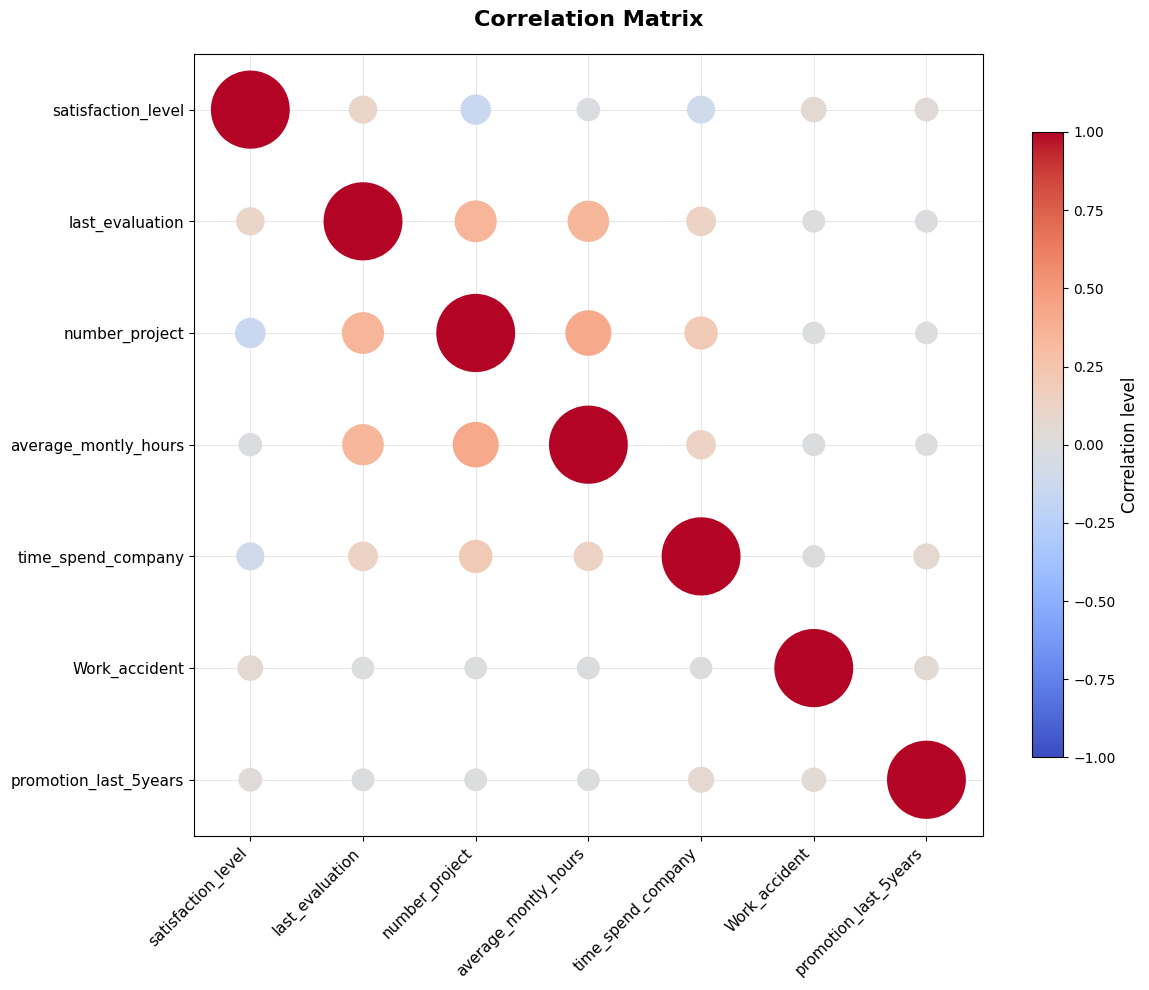

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('Employee_Attrition.csv', encoding='utf-8', sep=None, engine='python')
df.columns = df.columns.str.strip()

cols_to_fix = ['satisfaction_level', 'last_evaluation', 'number_project', 
               'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']

for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')
    df[col] = df[col].fillna(df[col].mean())

corr = df[cols_to_fix].corr()
labels = corr.columns
n = len(labels)


fig, ax = plt.subplots(figsize=(12, 10))

for i in range(n):
    for j in range(n):
        correlation = corr.iloc[i, j]
        
        # (abs * 0.35) represents the variation scale, while + 0.05 ensures a minimum marker size so that the points remain visible
        radius = (abs(correlation) * 0.25) + 0.1 
        
        color = plt.cm.coolwarm((correlation + 1) / 2)
        
        # Plot the point at (j, n−1−i) so that the marker overlays the grid lines.
        circle = plt.Circle((j, n - 1 - i), radius=radius, color=color, linewidth=0, zorder=2) 
        ax.add_patch(circle)


ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(labels[::-1], fontsize=11)

# Adjust the axis limits to align with the points so the grid lines pass through the center of each marker.
ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(-0.5, n - 0.5)

#Grid
ax.grid(True, color='lightgray', linestyle='-', linewidth=0.4, zorder=0)

#Legends
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=-1, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label('Correlation level', fontsize=12)

plt.title('Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

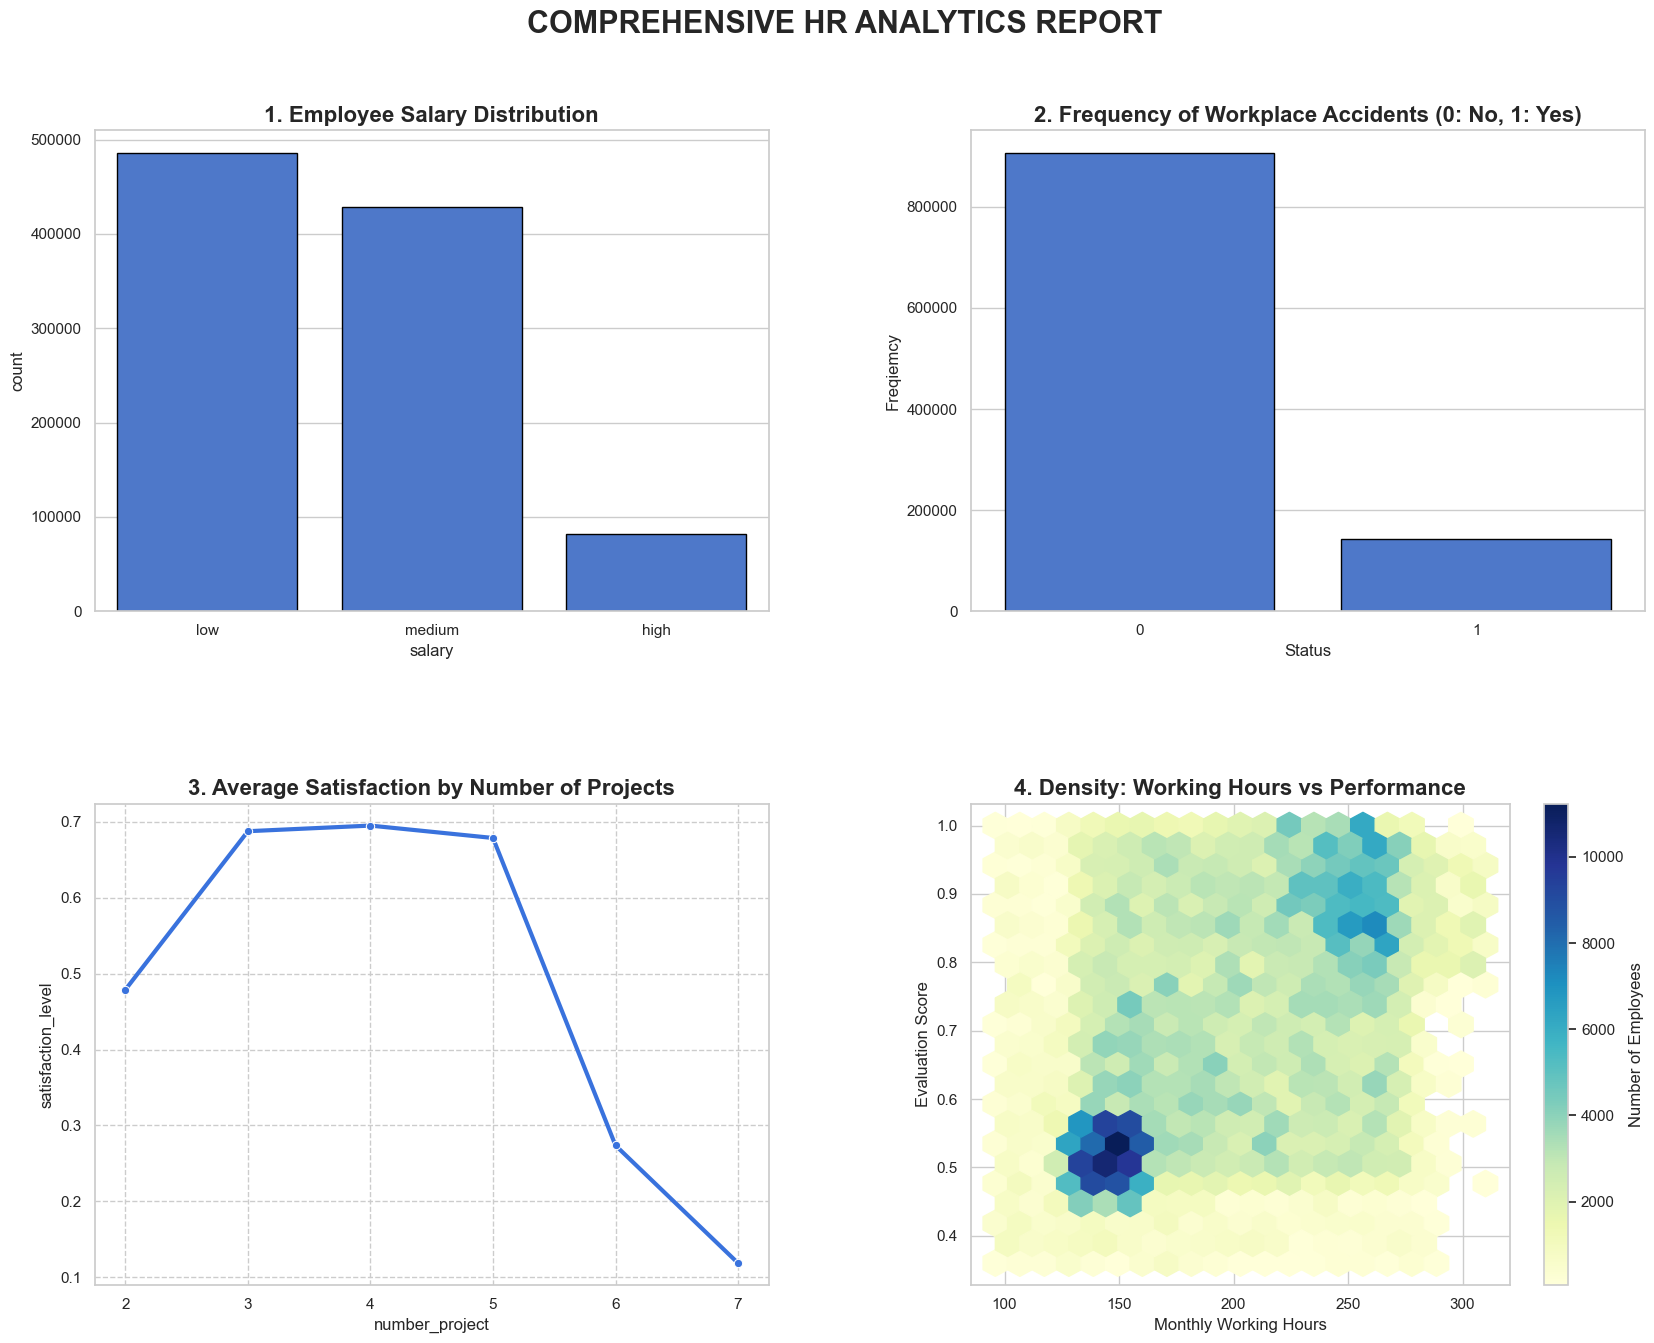

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Employee_Attrition.csv', sep=None, engine='python', encoding='utf-8-sig')
df.columns = df.columns.str.strip()

# --- Data processing ---
# Cast to integer to remove decimal formats such as 0.00 and 1.00.
df['Work_accident'] = pd.to_numeric(df['Work_accident'], errors='coerce').fillna(0).astype(int)

# Cast data type for each columns
cols_to_num = ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours']
for col in cols_to_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

#Dashboard settings
plt.rcParams['font.family'] = 'Arial'
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(20, 15))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- Chart 1: Salary Structure (Bar Chart) ---
plt.subplot(2, 2, 1)
sns.countplot(x='salary', data=df, order=['low', 'medium', 'high'], color='#3972dd', edgecolor='black')
plt.title('1. Employee Salary Distribution', fontsize=16, fontweight='bold')

# --- Chart 2: Workplace Accidents (0.00/1.00 Format Corrected) ---
plt.subplot(2, 2, 2)
sns.countplot(x='Work_accident', data=df, color="#3972dd", edgecolor='black')
plt.title('2. Frequency of Workplace Accidents (0: No, 1: Yes)', fontsize=16, fontweight='bold')
plt.ylabel('Freqiemcy')
plt.xlabel('Status')

# --- Chart 3: Satisfaction Trend by Number of Projects (Line Chart) ---
plt.subplot(2, 2, 3)
avg_sat = df.groupby('number_project')['satisfaction_level'].mean().reset_index()
sns.lineplot(x='number_project', y='satisfaction_level', data=avg_sat, marker='o', linewidth=3, color='#3972dd')
plt.title('3. Average Satisfaction by Number of Projects', fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--')

# --- CHART 4: Performance vs Working Hours Density (Hexbin) ---
plt.subplot(2, 2, 4)
hb = plt.hexbin(df['average_montly_hours'], df['last_evaluation'], gridsize=20, cmap='YlGnBu', mincnt=1)
plt.colorbar(hb, label='Number of Employees')
plt.title('4. Density: Working Hours vs Performance', fontsize=16, fontweight='bold')
plt.xlabel('Monthly Working Hours')
plt.ylabel('Evaluation Score')

# Overall title for the Dashboard
plt.suptitle('COMPREHENSIVE HR ANALYTICS REPORT', fontsize=22, fontweight='bold', y=0.96)
plt.show()




In [13]:
# 1. Define criteria for "High Turnover Risk"
# - satisfaction_level < 0.2 (Extremely dissatisfied)
# - last_evaluation > 0.8 (Very high performance)
# - average_montly_hours > 240 (Excessively high working hours)

risk_df = df[(df['satisfaction_level'] < 0.2) & 
             (df['last_evaluation'] > 0.8) & 
             (df['average_montly_hours'] > 240)].copy()

# 2. Rank and select Top 10
# Prioritize employees with the lowest satisfaction_level and the highest working hours
top_10_risk = risk_df.sort_values(by=['satisfaction_level', 'average_montly_hours'], 
                                   ascending=[True, False]).head(5)

# 3. Display Top 10 table
print("--- TOP 10 EMPLOYEES WITH HIGH TURNOVER RISK ---")
display(top_10_risk[['Emp ID', 'dept', 'salary', 'satisfaction_level', 'last_evaluation', 'average_montly_hours']])

top_10_risk = risk_df.sort_values(by=['satisfaction_level', 'average_montly_hours'], 
                                   ascending=[False, True]).head(5)

# 3. Display Top 10 table
print("--- TOP 10 MOST COMMITTED EMPLOYEES ---")
display(top_10_risk[['Emp ID', 'dept', 'salary', 'satisfaction_level', 'last_evaluation', 'average_montly_hours']])

--- TOP 10 EMPLOYEES WITH HIGH TURNOVER RISK ---


,Emp ID,dept,salary,satisfaction_level,last_evaluation,average_montly_hours
26608,1964.0,support,low,0.09,0.89,310.0
42397,1964.0,support,low,0.09,0.89,310.0
58186,1964.0,support,low,0.09,0.89,310.0
73975,1964.0,support,low,0.09,0.89,310.0
89764,1964.0,support,low,0.09,0.89,310.0


--- TOP 10 MOST COMMITTED EMPLOYEES ---


,Emp ID,dept,salary,satisfaction_level,last_evaluation,average_montly_hours
19570,9002.0,RandD,medium,0.19,0.81,245.0
35359,9002.0,RandD,medium,0.19,0.81,245.0
51148,9002.0,RandD,medium,0.19,0.81,245.0
66937,9002.0,RandD,medium,0.19,0.81,245.0
82726,9002.0,RandD,medium,0.19,0.81,245.0


In [20]:
# 1. Prepare the data (convert to numeric type and perform calculation)
df['time_spend_company'] = pd.to_numeric(df['time_spend_company'], errors='coerce')
tenure_table = df.groupby('dept')['time_spend_company'].mean().sort_values(ascending=False).reset_index()
tenure_table.columns = ['Department', 'Average Years of Service']

# 2. Define column width
name_width = 20
num_width = 30

# 3. Print table title (center aligned)

print(f"{'DEPARTMENT TENURE RANKING':^{name_width + num_width + 3}} \n")

print(f"{'DEPARTMENT':^{name_width}}  {'AVERAGE YEARS':^{num_width}}")


# 4. Print each row of data (center align text and numbers)
for _, row in tenure_table.iterrows():
    print(f"{row['Department']:^{name_width}}  {row['Average Years of Service']:^{num_width}.2f}")

              DEPARTMENT TENURE RANKING               

     DEPARTMENT               AVERAGE YEARS         
     management                    4.30             
     marketing                     3.57             
       sales                       3.53             
     accounting                    3.52             
    product_mng                    3.48             
         IT                        3.47             
     technical                     3.41             
      support                      3.39             
       RandD                       3.37             
         hr                        3.36             


**3. Conclusion and Recommendation for Business**

**Based on the analyses above, several valuable insights can be identified as follows:**

**1/ The lingering paradox:** As shown in the initial correlation chart, there is a strong positive correlation between _last_evaluation_, number_project, and average_monthly_hours . When cross-referencing with the top 10 employees at risk of leaving, an important pattern emerges: **high-performing employees are consistently associated with an enormous workload as well as cyclical career advancement, yet the salaries they receive are mostly classified at the low level**. Therefore, this raises a critical concern regarding the company’s compensation policies for its employees. So the question remains: **are employees who are willing to dedicate themselves to the company also willing to sacrifice their personal lives and well-being in order to continue staying with the organization?**

**2/ The burnout threshold:** The Hexbin chart "Density: Working Hours vs Performance" reveals two distinct clusters of employees exhibiting different turnover behaviors. The first cluster consists of employees working around 150 hours per month with extremely high evaluation scores (>0.8). Real data reveals a surprisingly critical threshold: every employee assigned 7 projects has left the company. This is no longer random attrition but rather a systemic failure in resource management. When an employee is responsible for **7 projects**, it effectively means they are operating at around **310 working hours** per month. This is equivalent to approximately **14 working hours per day** in a standard **5-day workweek**, or about **10 hours per day** if they work continuously throughout the entire month without rest.
ours per

**3/ HR hotspot:** Although departments such as _Sales_, _Technical_, and _Support_ have the highest number of employees leaving due to their larger department sizes, the **Human Resources (HR) department actually has the highest relative turnover rate**. This serves as an extremely serious warning signal for leadership: when the very people responsible for retaining talent are themselves leaving the organization, it reflects a major gap in senior management culture. The Management department has the lowest turnover rate, which can be explained by their higher level of autonomy and better compensation. However, the significant gap between Management and execution-level departments (_Technical/Support_) in terms of satisfaction and working hours suggests a breakdown in communication and mutual understanding across management layers.

**RECOMMENDED SOLUTIONS**

**Reforming the promotion and compensation mechanism based on contribution value**

1. Build a flexible salary band: For employees with outstanding evaluations (Last Evaluation > 0.8) but without available managerial positions for promotion, the company should implement a merit-based salary increase mechanism that exceeds the standard pay range to retain them. Do not let them feel that the only reward for performing well is simply… being assigned more work.

2. Provide titles and compensation packages equivalent to managerial positions for employees who possess master-level technical expertise but do not wish to take on people-management responsibilities.

**Project Limition**

**The data reveals a harsh reality:** 100% of employees assigned 7 projects eventually left the company. This represents the most serious management mistake, yet it is also the easiest one to fix.

+ **Implementation:** Leadership should enforce a strict rule: no employee should be assigned more than 5 projects, regardless of how capable they are.

+ **Why it works:** This protects top-performing employees from burnout. Retaining a highly capable existing employee is always far less costly than spending resources to recruit and train a new one.

**Conduct stay interviews to understand employee conditions at the 3.5-year mark**

+ Instead of waiting until employees submit resignation letters to conduct exit interviews, managers should proactively conduct stay interviews when employees reach the 3.5-year milestone.